# Case Study 4 : IMDB Sentiment Analysis with LSTM
**Objective:** Build an LSTM model for binary sentiment classification on the IMDB dataset.
**Covers:** Text preprocessing, LSTM model design, evaluation metrics, error analysis.

In [1]:
!pip install torch numpy matplotlib seaborn scikit-learn --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import re, random, collections
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load IMDB Dataset

In [3]:
# Download IMDB dataset using keras (available in Colab by default)
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LEN    = 200

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
print(f'Train: {len(X_train_raw)}, Test: {len(X_test_raw)}')
print(f'Sample label: {y_train[0]} | Sequence length: {len(X_train_raw[0])}')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: 25000, Test: 25000
Sample label: 1 | Sequence length: 218


## 2. Text Preprocessing

Padded train shape: (25000, 200)
Padded test shape:  (25000, 200)


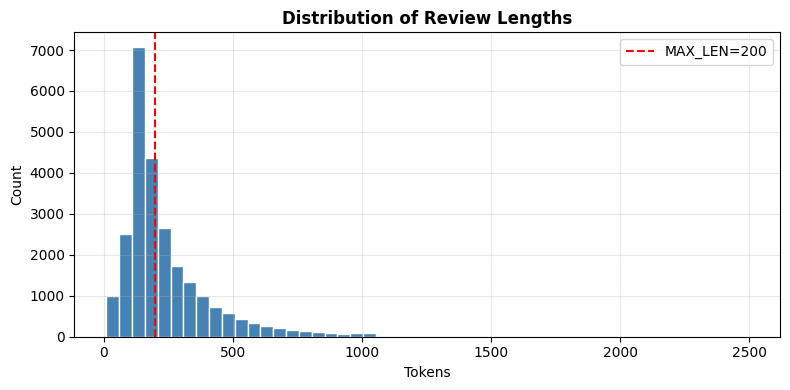

Mean length: 239 | Max: 2494 | >200 tokens: 42.7%


In [4]:
# Pad/truncate sequences to fixed length
X_train_pad = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_raw,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Padded train shape: {X_train_pad.shape}')
print(f'Padded test shape:  {X_test_pad.shape}')

# Visualize sequence length distribution
lengths = [len(x) for x in X_train_raw]
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Distribution of Review Lengths', fontweight='bold')
plt.xlabel('Tokens'); plt.ylabel('Count')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Mean length: {np.mean(lengths):.0f} | Max: {max(lengths)} | >200 tokens: {sum(l>200 for l in lengths)/len(lengths)*100:.1f}%')

In [5]:
# Convert to PyTorch tensors
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(IMDBDataset(X_train_pad, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(IMDBDataset(X_test_pad,  y_test),  batch_size=64)
print('DataLoaders ready.')

DataLoaders ready.


## 3. LSTM Model Design

In [6]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(
            embed_dim, hidden_size, num_layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))       # (B, T, E)
        out, (h, _) = self.lstm(embedded)                # out: (B, T, 2H)
        # Concatenate final forward and backward hidden states
        hidden = torch.cat([h[-2], h[-1]], dim=1)        # (B, 2H)
        return self.fc(self.dropout(hidden)).squeeze(1)  # (B,)

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE, embed_dim=128,
    hidden_size=256, num_layers=2, dropout=0.3
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SentimentLSTM(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)

Total parameters: 4,928,001


## 4. Training

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

EPOCHS = 5
train_losses, test_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))
    scheduler.step()

    # Evaluate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = torch.sigmoid(model(xb)).cpu().numpy()
            all_preds.extend((preds > 0.5).astype(int))
            all_labels.extend(yb.numpy().astype(int))
    acc = accuracy_score(all_labels, all_preds)
    test_accs.append(acc)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {train_losses[-1]:.4f} | Test Acc: {acc:.4f}')

Epoch 1/5 | Loss: 0.6735 | Test Acc: 0.6490
Epoch 2/5 | Loss: 0.6049 | Test Acc: 0.7250
Epoch 3/5 | Loss: 0.4771 | Test Acc: 0.7885
Epoch 4/5 | Loss: 0.4061 | Test Acc: 0.8303
Epoch 5/5 | Loss: 0.3472 | Test Acc: 0.8377


## 5. Evaluation Metrics

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.85      0.82      0.83     12500
    Positive       0.82      0.86      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



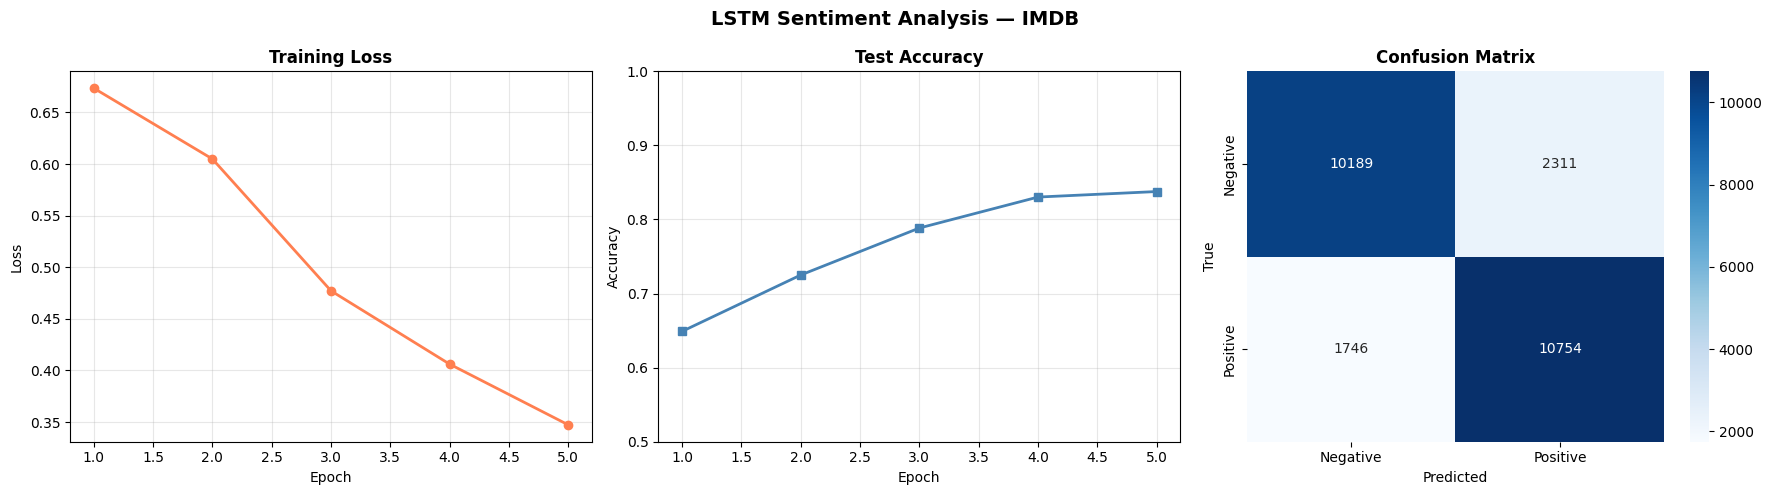

In [8]:
print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(range(1, EPOCHS+1), train_losses, 'o-', color='coral', linewidth=2)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(range(1, EPOCHS+1), test_accs, 's-', color='steelblue', linewidth=2)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0); axes[1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
axes[2].set_title('Confusion Matrix', fontweight='bold')
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.suptitle('LSTM Sentiment Analysis — IMDB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab4_imdb_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Error Analysis

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Errors in first 500 samples: 85

=== Sample Misclassified Reviews ===
True: NEGATIVE | Predicted: POSITIVE | Confidence: 0.97
Review snippet: <START> hollywood had a long love affair with bogus arabian nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long si

True: NEGATIVE | Predicted: POSITIVE | Confidence: 0.83
Review snippet: <START> i started watching this because i thought it was a really shitty porno as i kept watching the only thrill i got from this movie was finding out what the name of it was so i could look it up an

True: POSITIVE | Predicted: NEGATIVE | Confidence: 0.56
Review snippet: <START> how managed to avoid attention remains a mystery a potent mix of comedy and crime this one takes chances where tarantino plays it safe with the hollywood formula the risks don't always pay off



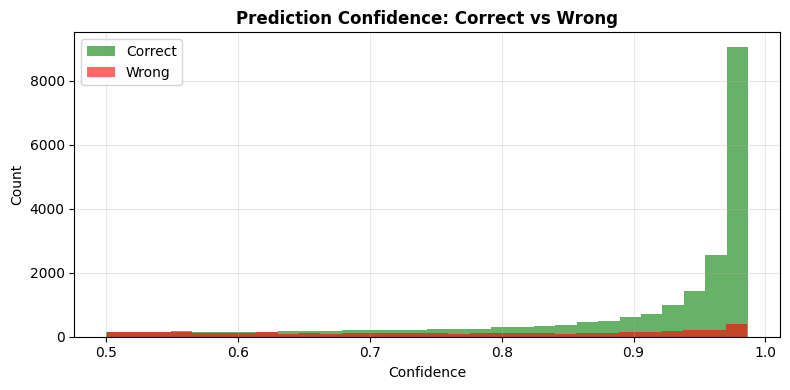

Error analysis: wrong predictions tend to have lower confidence (near 0.5).


In [9]:
# Collect prediction probabilities for error analysis
word_index = imdb.get_word_index()
idx2word   = {v+3: k for k, v in word_index.items()}
idx2word.update({0:'<PAD>', 1:'<START>', 2:'<UNK>', 3:'<UNUSED>'})

def decode_review(seq):
    return ' '.join([idx2word.get(i, '?') for i in seq if i > 0])

# Get high-confidence wrong predictions
model.eval()
errors = []
with torch.no_grad():
    for i in range(min(500, len(X_test_pad))):
        x = torch.tensor(X_test_pad[i:i+1], dtype=torch.long).to(device)
        prob = torch.sigmoid(model(x)).item()
        pred = int(prob > 0.5)
        true = int(y_test[i])
        if pred != true:
            errors.append({'prob': prob, 'pred': pred, 'true': true, 'idx': i})

print(f'Errors in first 500 samples: {len(errors)}')
print(f'\n=== Sample Misclassified Reviews ===')
for e in errors[:3]:
    sentiment = lambda x: 'POSITIVE' if x == 1 else 'NEGATIVE'
    print(f"True: {sentiment(e['true'])} | Predicted: {sentiment(e['pred'])} | Confidence: {max(e['prob'], 1-e['prob']):.2f}")
    review_text = decode_review(X_test_raw[e['idx']][:50])
    print(f"Review snippet: {review_text[:200]}")
    print()

# Confidence distribution of errors vs correct
all_probs, all_correct = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probs = torch.sigmoid(model(xb)).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        for p, prob, gt in zip(preds, probs, yb.numpy().astype(int)):
            all_probs.append(abs(prob - 0.5) + 0.5)  # confidence
            all_correct.append(int(p == gt))

correct_conf = [all_probs[i] for i in range(len(all_correct)) if all_correct[i] == 1]
wrong_conf   = [all_probs[i] for i in range(len(all_correct)) if all_correct[i] == 0]

plt.figure(figsize=(8, 4))
plt.hist(correct_conf, bins=30, alpha=0.6, color='green',  label='Correct')
plt.hist(wrong_conf,   bins=30, alpha=0.6, color='red',    label='Wrong')
plt.title('Prediction Confidence: Correct vs Wrong', fontweight='bold')
plt.xlabel('Confidence'); plt.ylabel('Count')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lab4_error_analysis.png', dpi=150)
plt.show()
print('Error analysis: wrong predictions tend to have lower confidence (near 0.5).')

## 7. Explanation

### Why Bidirectional LSTM for Sentiment?
- A **forward** LSTM reads left→right, missing context from later words.
- A **bidirectional** LSTM also reads right→left, capturing full context.
- Example: *"The film was not bad at all"* — the word *not* matters for understanding *bad*, and a BiLSTM captures this better.

### Evaluation Metrics
| Metric | Formula | What it measures |
|--------|---------|------------------|
| Accuracy | (TP+TN)/Total | Overall correctness |
| Precision | TP/(TP+FP) | Of all predicted positives, how many are correct |
| Recall | TP/(TP+FN) | Of all actual positives, how many were found |
| F1 Score | 2×P×R/(P+R) | Balance between precision and recall |

### Error Analysis Findings
- Most errors cluster near **confidence ≈ 0.5** — the model is uncertain on hard examples.
- Common failure cases: sarcasm, mixed sentiment, domain-specific vocabulary, very long reviews.